In [1]:
import numpy as np
from sympleq.core.symmetries.pauli import pauli_reduce
from sympleq.core.symmetries.clifford import clifford_phase_decomposition, qudit_cost
from sympleq.core.symmetries.block_decomposition import block_decompose, block_decompose_optimal, block_indexes
from sympleq.models.Ising import ising_chain_hamiltonian, ising_2d_hamiltonian, heuristic_clifford_symmetry
from sympleq.core.circuits import Gate, Circuit, gate_to_circuit
import numpy as np
from itertools import combinations_with_replacement, permutations, product

In [2]:

N = 4
J = 1
h = 0.5
periodic = False
H = ising_chain_hamiltonian(N, J, h, periodic=periodic)
print(H)


(1+0j)  |x0z1 x0z1 x0z0 x0z0 | 0 
(1+0j)  |x0z0 x0z1 x0z1 x0z0 | 0 
(1+0j)  |x0z0 x0z0 x0z1 x0z1 | 0 
(0.5+0j)|x1z0 x0z0 x0z0 x0z0 | 0 
(0.5+0j)|x0z0 x1z0 x0z0 x0z0 | 0 
(0.5+0j)|x0z0 x0z0 x1z0 x0z0 | 0 
(0.5+0j)|x0z0 x0z0 x0z0 x1z0 | 0 



Lmin_star (theory half-dim): 2
Block sizes: [4, 4] Q_alg: 2
Got T and S
Qubit cost is  2


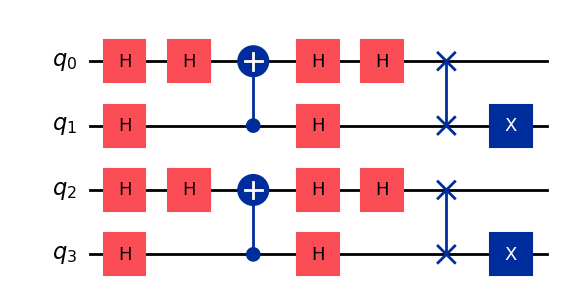

In [3]:
F = heuristic_clifford_symmetry(N, periodic=periodic)
# print(F.symplectic)
S, T = block_decompose_optimal(F.symplectic, 2)

h_S, h_T = clifford_phase_decomposition(F.symplectic, F.phase_vector, S, T, int(H.lcm))
S_gate = Gate('S', F.qudit_indices, S, F.dimensions, h_S)
T_gate = Gate('T', F.qudit_indices, T, F.dimensions, h_T)

assert F == Circuit(F.dimensions, [T_gate.inv(), S_gate, T_gate]).composite_gate()

assert H.to_standard_form() == F.act(H).to_standard_form()
assert T_gate.act(S_gate.act(T_gate.inv().act(H))).to_standard_form() == H.to_standard_form()

assert S_gate.act(T_gate.inv().act(H)).to_standard_form() == T_gate.inv().act(H).to_standard_form()

print('Got T and S')
print('Qubit cost is ', qudit_cost(S_gate))
imF = gate_to_circuit(F).circuit_image()
imT = gate_to_circuit(T_gate).circuit_image()
imS = gate_to_circuit(S_gate).circuit_image()

# imF.draw(output='mpl')
# imT.draw(output='mpl')
imS.draw(output='mpl')

In [44]:
### Test F and F unitary

C_F = gate_to_circuit(F)
# C_S = gate_to_circuit(S)
# C_T = gate_to_circuit(T)
assert C_F.act(H).to_standard_form() == H.to_standard_form()

U_F = C_F.unitary().toarray()
H_hilbert = H.to_hilbert_space().toarray()
assert np.all(np.abs(U_F @ H_hilbert @ U_F.conj().T - H_hilbert) < 1e-8)

print('F passed')
### Test decomposition symmetry (Pauli-level)

H_prime = T_gate.inv().act(H)
H_rec = Circuit(F.dimensions, [T_gate.inv(), S_gate, T_gate]).act(H)

# For p=2 the gate_to_circuit Pauli correction drops odd phase components,
# so we verify invariance at the Pauli level using the reconstructed F.
assert H_rec.to_standard_form() == H.to_standard_form()
assert S_gate.act(H_prime).to_standard_form() == H_prime.to_standard_form()
print('F (via S,T) passed (Pauli check)')
print('H_prime:\n', H_prime)


F passed
F (via S,T) passed (Pauli check)
H_prime:
 (1+0j)  |x0z1 x1z0 x0z1 x0z0 | 0 
(1+0j)  |x0z0 x0z0 x0z1 x1z1 | 1 
(1+0j)  |x0z0 x0z1 x1z0 x0z1 | 0 
(0.5+0j)|x1z0 x0z0 x0z0 x0z0 | 0 
(0.5+0j)|x0z0 x0z0 x1z0 x0z0 | 0 
(0.5+0j)|x0z0 x0z0 x0z0 x1z0 | 0 
(0.5+0j)|x0z0 x1z0 x0z0 x0z0 | 0 



In [45]:
## test S unitary

C_S = gate_to_circuit(S_gate)
U_S = C_S.unitary().toarray()
H_prime_hilbert = H_prime.to_hilbert_space().toarray()
# print(H_prime_hilbert)
assert np.all(np.abs(U_S @ H_prime_hilbert @ U_S.conj().T - H_prime_hilbert) < 1e-8)
assert np.all(U_S @ H_prime_hilbert - H_prime_hilbert @ U_S < 1e-8)
print('S passed')

S passed


In [46]:
from sympleq.core.paulis import PauliString
blocks = block_indexes(S_gate.symplectic)
print(blocks)
# # print(H_prime_hilbert)
# ps_test = PauliString(np.asarray([0, 0, 0, 1, 0, 0]), [2, 2, 2])

# print(F.act(ps_test))

print(F.symplectic)
print(S_gate.symplectic)
print(T_gate.symplectic)


[[0, 1], [2, 3]]
[[0 0 0 1 1 1 1 1]
 [0 0 1 0 1 1 1 1]
 [0 1 0 0 1 1 1 1]
 [1 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0 0]]
[[0 1 0 0 1 0 0 0]
 [1 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 1 0]
 [0 0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]]
[[1 0 0 0 1 1 1 1]
 [0 0 1 0 1 0 1 1]
 [0 0 0 1 1 0 1 0]
 [0 1 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 0]]


In [47]:
n_local_blocks = len(blocks)

n_local_eigenstates = np.prod([2**len(blocks[i]) for i in range(n_local_blocks)])  # should really be dim[i]**len(...
local_eigenstate_dimension = [2**len(blocks[i]) for i in range(n_local_blocks)]


local_eigenstates = []
local_eigenenergies = []
for i in range(n_local_blocks):
    block_eigenstates = []
    block_energies = []
    block = blocks[i]
    C_loc = C_S.local_circuit(block)
    print(C_loc)
    U_loc = C_loc.unitary().toarray()
    es_loc, ev_loc = np.linalg.eig(U_loc)
    # print(f"Local block {i} unitary eigenvalues:\n", es_loc)
    for i in range(len(es_loc)):
        block_eigenstates.append(ev_loc[:, i])
        block_energies.append(es_loc[i])
    local_eigenstates.append(block_eigenstates)
    local_eigenenergies.append(block_energies)

print("Local eigenenergies:\n", local_eigenenergies)
print("Local eigenstates:\n", local_eigenstates)


H [0]
H [1]
H [0]
SUM [1 0]
H [0]
H_inv [0]
H_inv [1]
SWAP [1 0]
Pauli(X^1Z^0_1) [1]

H [0]
H [1]
H [0]
SUM [1 0]
H [0]
H_inv [0]
H_inv [1]
SWAP [1 0]
Pauli(X^1Z^0_3) [1]

Local eigenenergies:
 [[np.complex128(1.1102230246251565e-16+0.9999999999999991j), np.complex128(-2.7755575615628914e-17-0.9999999999999993j), np.complex128(0.9999999999999993-2.4980018054066017e-16j), np.complex128(0.9999999999999999-3.642919299551295e-17j)], [np.complex128(1.1102230246251565e-16+0.9999999999999991j), np.complex128(-2.7755575615628914e-17-0.9999999999999993j), np.complex128(0.9999999999999993-2.4980018054066017e-16j), np.complex128(0.9999999999999999-3.642919299551295e-17j)]]
Local eigenstates:
 [[array([-1.93496508e-16-5.00000000e-01j, -5.00000000e-01-1.11022302e-16j,
        5.00000000e-01+0.00000000e+00j,  1.40900310e-16+5.00000000e-01j]), array([-5.55111512e-17+5.00000000e-01j, -5.00000000e-01-5.55111512e-17j,
        5.00000000e-01+0.00000000e+00j,  1.94289029e-16-5.00000000e-01j]), array([ 0.6

In [ ]:
# Simple single example eigenstate from local blocks

index_block_1 = 1
index_block_2 = 0

eigenstate = np.kron(local_eigenstates[0][index_block_1], local_eigenstates[1][index_block_2])
S_eigenenergy = local_eigenenergies[0][index_block_1] * local_eigenenergies[1][index_block_2]

print(np.round(eigenstate, 3))

assert np.all(np.abs(U_S @ eigenstate - S_eigenenergy * eigenstate) < 1e-8)

print(eigenstate @ H_prime_hilbert @ eigenstate)

print(H_prime_hilbert @ eigenstate)


[ 0.25-0.j    0.  -0.25j -0.  +0.25j -0.25+0.j    0.  +0.25j  0.25+0.j
 -0.25-0.j   -0.  -0.25j -0.  -0.25j -0.25-0.j    0.25+0.j    0.  +0.25j
 -0.25-0.j   -0.  +0.25j  0.  -0.25j  0.25+0.j  ]
-5.551115123125783e-17j
[-0.5-0.5j -0.5+0.5j -0.5-0.5j  0.5-0.5j -0.5-0.5j -0.5+0.5j  0.5+0.5j
 -0.5+0.5j -0.5+0.5j  0.5+0.5j -0.5+0.5j -0.5-0.5j  0.5-0.5j -0.5-0.5j
 -0.5+0.5j -0.5-0.5j]


In [14]:


# Now build tensor product eigenstates
print(n_local_blocks)
print(n_local_eigenstates)
eigenstate_indexes_by_block = list(product([0, 1, 2, 3], repeat=n_local_blocks))
print(len(eigenstate_indexes_by_block))
n_eigenstates = 2**N


def build_tensor_product_eigenstate(eigenstates, indexes):
    assert len(eigenstates) == len(indexes)
    eigenstate = eigenstates[indexes[0]]
    for i in range(1, len(indexes)):
        eigenstate = np.kron(eigenstate, eigenstates[indexes[i]])
    return eigenstate


full_eigenstates = np.zeros((2**N, 2**N), dtype=complex)
for i, eigenstate_indexes in enumerate(eigenstate_indexes_by_block):
    print(eigenstate_indexes)
    eigenstate = build_tensor_product_eigenstate(local_eigenstates, eigenstate_indexes)
    assert np.isclose(1, np.sum(np.abs(eigenstate)**2))
    energy = local_eigenenergies[eigenstate_indexes[0]][0] * local_eigenenergies[eigenstate_indexes[1]][0]
    # print('Eigenstate ', eigenstate)
    # print('Energy ', energy)
    H_es = H_prime_hilbert @ eigenstate
    # print('Energy is ', np.round(H_es, 2))
    assert np.all(np.abs(U_S @ eigenstate - eigenstate * energy) < 1e-8)

    # Check they are eigenstates of H_prime as well - they may have different energies

    # print(eigenstate @ H_prime_hilbert @ eigenstate)
    # print(np.round(eigenstate, 8))
    full_eigenstates[:, i] = eigenstate

# print('H\' Unitary:\n')
# print(H_prime_hilbert)
# print('H\' in eigenbasis:\n')
# print(np.round(full_eigenstates.conj().T @ H_prime_hilbert @ full_eigenstates, 8))

# print(full_eigenstates)

2
16
16
(0, 0)


AssertionError: 

In [ ]:


# Now build tensor product eigenstates
n_local_eigenstates = np.prod([2**len(blocks[i]) for i in range(n_local_blocks)])  # should really be dim[i]**len(...
print(n_local_blocks)
print(n_local_eigenstates)
eigenstate_indexes_by_block = list(product([0, 1, 2, 3], repeat=n_local_blocks))
print(len(eigenstate_indexes_by_block))
n_eigenstates = 2**N


def build_tensor_product_eigenstate(local_eigenstates, eigenstate_indexes):
    assert len(local_eigenstates) == len(eigenstate_indexes)
    eigenstate = local_eigenstates[eigenstate_indexes[0]][:,0]
    for i in range(1, len(eigenstate_indexes)):
        eigenstate = np.kron(eigenstate, local_eigenstates[eigenstate_indexes[i]][:, 0])
    return eigenstate


full_eigenstates = np.zeros((2**N, 2**N), dtype=complex)
for i, eigenstate_indexes in enumerate(eigenstate_indexes_by_block):
    print(eigenstate_indexes)
    eigenstate = build_tensor_product_eigenstate(local_eigenstates, eigenstate_indexes)
    assert np.isclose(1, np.sum(np.abs(eigenstate)**2))
    energy = local_eigenenergies[eigenstate_indexes[0]][0] * local_eigenenergies[eigenstate_indexes[1]][0]
    # print('Eigenstate ', eigenstate)
    # print('Energy ', energy)
    H_es = H_prime_hilbert @ eigenstate
    # print('Energy is ', np.round(H_es, 2))
    assert np.all(np.abs(U_S @ eigenstate - eigenstate * energy) < 1e-8)

    # Check they are eigenstates of H_prime as well - they may have different energies

    # print(eigenstate @ H_prime_hilbert @ eigenstate)
    # print(np.round(eigenstate, 8))
    full_eigenstates[:, i] = eigenstate

# print('H\' Unitary:\n')
# print(H_prime_hilbert)
# print('H\' in eigenbasis:\n')
# print(np.round(full_eigenstates.conj().T @ H_prime_hilbert @ full_eigenstates, 8))

# print(full_eigenstates)

2
16
16
(0, 0)
(0, 1)
(0, 2)


IndexError: list index out of range